<a href="https://colab.research.google.com/github/ainfitribasri/Analisis-Deret-Waktu/blob/main/Tugas_Minggu_5_Pemodelan_Data_Deret_Waktu_Stasioner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS KELOMPOK 2
## Pemodelan Data Deret Waktu Stasioner

**Anggota Kelompok:**
1. Ain Fitri Basri — M0501251051
2. Alma Alifia Halimatunnisa — M0501251004
3. Aridha Pebriani Kusmiran — M0501251049

In [1]:
!pip install PythonTsa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 9.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from scipy.stats import boxcox,  boxcox_llf

import warnings
warnings.filterwarnings("ignore")

In [3]:
%load_ext rpy2.ipython

In [5]:
%%R
install.packages('TSA')
library(TSA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘TTR’, ‘quantmod’, ‘tseries’

trying URL 'https://cran.rstudio.com/src/contrib/TTR_0.24.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/quantmod_0.4.29.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tseries_0.10-63.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/TSA_1.3.1.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpIJZKY9/downloaded_packages’

Attaching package: ‘TSA’

The following objects are masked from ‘package:stats’:

    acf, arima

The following object is masked from ‘package:utils’:

    tar



In [6]:
np.random.seed(104)

#1. Simulasi Deret MA(1)

In [7]:
from statsmodels.tsa.arima_process import ArmaProcess

# Simulasi deret MA(1)
# theta = 0.6, n = 120

ma1_process = ArmaProcess(
    ar=[1],
    ma=[1, 0.6]
)

data_ma1 = ma1_process.generate_sample(
    nsample=120,
    burnin=200
)

In [8]:
print("Jumlah observasi:", len(data_ma1))
print(data_ma1[:10])

Jumlah observasi: 120
[-1.22050594 -1.1260478  -0.46130182 -1.06158661 -1.00370401  0.47169296
  0.64551969 -0.52106191 -1.59228897  0.05690745]


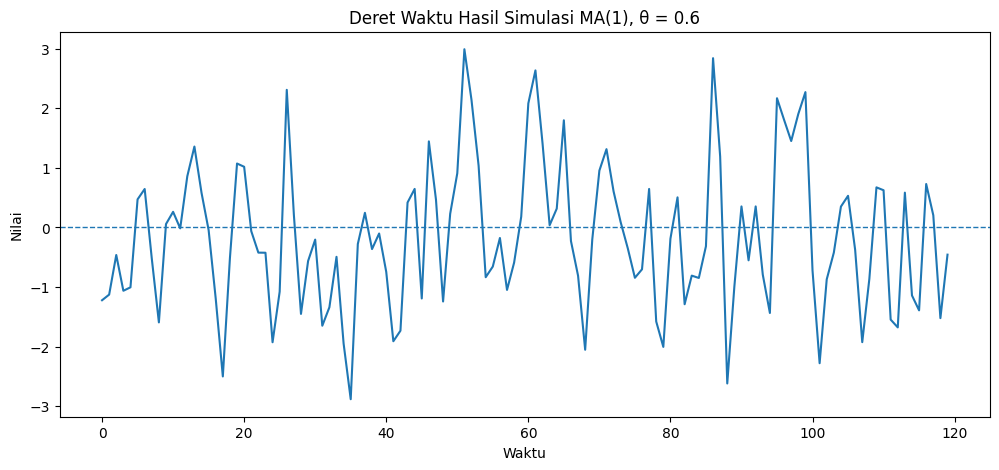

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(data_ma1)

plt.title("Deret Waktu Hasil Simulasi MA(1), θ = 0.6")
plt.xlabel("Waktu")
plt.ylabel("Nilai")

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.show()

Deret waktu hasil simulasi MA(1) dengan parameter \(\theta=0.6\) dan panjang amatan \(n=120\) menunjukkan fluktuasi di sekitar nilai tengah yang relatif konstan. Tidak terlihat adanya pola tren maupun perubahan varians yang sistematis sepanjang waktu. Dengan demikian, secara visual deret hasil simulasi menunjukkan karakteristik deret waktu stasioner.

#2. Pembagian Data Latih dan Data Uji

In [12]:
# Pembagian data latih dan data uji
n_train_ma1 = int(0.8 * len(data_ma1))

train_ma1 = data_ma1[:n_train_ma1]
test_ma1 = data_ma1[n_train_ma1:]

print("Jumlah seluruh data :", len(data_ma1))
print("Jumlah data latih   :", len(train_ma1))
print("Jumlah data uji     :", len(test_ma1))

Jumlah seluruh data : 120
Jumlah data latih   : 96
Jumlah data uji     : 24


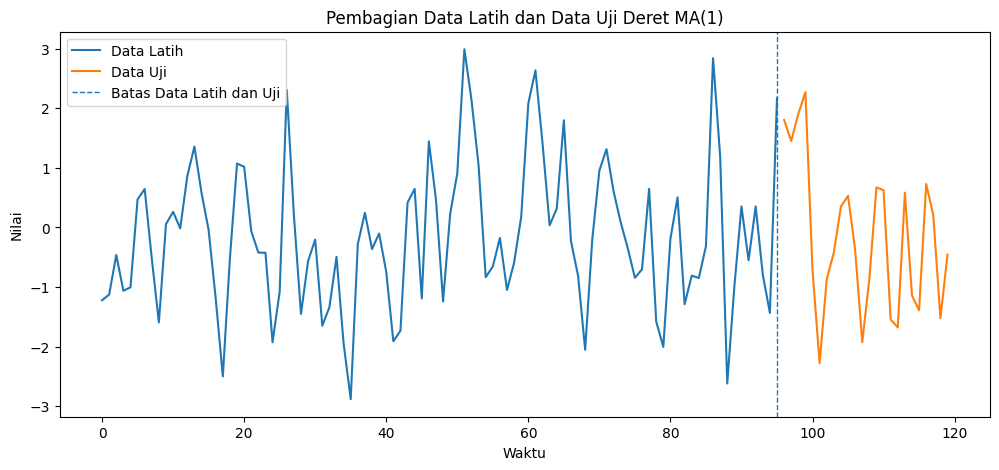

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(train_ma1)),
    train_ma1,
    label="Data Latih"
)

plt.plot(
    range(len(train_ma1), len(data_ma1)),
    test_ma1,
    label="Data Uji"
)

plt.axvline(
    x=len(train_ma1)-1,
    linestyle="--",
    linewidth=1,
    label="Batas Data Latih dan Uji"
)

plt.title("Pembagian Data Latih dan Data Uji Deret MA(1)")
plt.xlabel("Waktu")
plt.ylabel("Nilai")
plt.legend()
plt.show()

Deret hasil simulasi MA(1) sebanyak 120 observasi dibagi menjadi 80% data latih dan 20% data uji. Dengan demikian, sebanyak 96 observasi pertama digunakan sebagai data latih dan 24 observasi terakhir sebagai data uji. Pembagian dilakukan berdasarkan urutan waktu tanpa pengacakan untuk mempertahankan struktur temporal deret. Proporsi 80:20 dipilih karena menyediakan data latih yang cukup untuk identifikasi dan estimasi model, serta data uji yang memadai untuk mengevaluasi kemampuan peramalan.

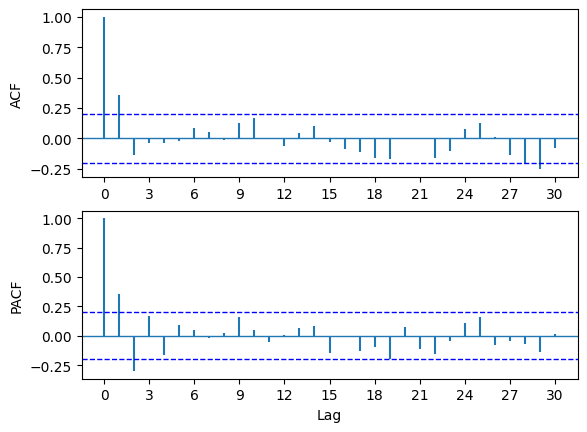

In [14]:
acf_pacf_fig(
    train_ma1,
    both=True,
    lag=30
)

plt.show()

In [15]:
train_ma1_r = np.asarray(train_ma1)

In [16]:
%%R -i train_ma1_r

library(TSA)

eacf(as.numeric(train_ma1_r))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o o  o  o  o 
1 x x o o o o o o o o o  o  o  o 
2 x x o o o o o o o o o  o  o  o 
3 x x o o o o o o o o o  o  o  o 
4 x x o o o o o o o o o  o  o  o 
5 x x x o o o o o o o o  o  o  o 
6 x o o o o o o o o o o  o  o  o 
7 x o x o o o o o o o o  o  o  o 


#3. Identifikasi Model berdasarkan ACF, PACF, dan EACF.
Plot ACF data latih menunjukkan autokorelasi yang signifikan pada lag 1, sedangkan sebagian besar lag setelahnya berada di dalam batas kepercayaan. Pola tersebut menunjukkan ACF yang mengalami cut-off setelah lag 1. Sementara itu, plot PACF menunjukkan pola yang cenderung meluruh (tailing off), dengan spike signifikan pada beberapa lag awal dan nilai autokorelasi parsial yang kemudian semakin kecil. Pola ACF dan PACF tersebut mengarah pada model MA(1). Hasil EACF memperkuat identifikasi tersebut, dengan pola o yang membentuk wilayah segitiga dengan titik sudut pada sekitar \(p=0\) dan \(q=1\). Berdasarkan ketiga pendekatan tersebut, model tentatif yang dipilih adalah MA(1) atau ARMA(0,1).

#Fitting model MA(1)

In [17]:
# Pengepasan model MA(1) pada data latih
model_ma1 = ARIMA(
    train_ma1,
    order=(0, 0, 1)
).fit()

print(model_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -140.019
Date:                Wed, 23 Sep 2026   AIC                            286.039
Time:                        02:00:49   BIC                            293.732
Sample:                             0   HQIC                           289.148
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1542      0.187     -0.825      0.410      -0.521       0.212
ma.L1          0.6817      0.092      7.432      0.000       0.502       0.862
sigma2         1.0754      0.155      6.941      0.0

Berdasarkan hasil identifikasi menggunakan ACF, PACF, dan EACF, dilakukan pengepasan model MA(1) atau ARIMA(0,0,1) terhadap 96 observasi data latih. Hasil estimasi menunjukkan koefisien MA(1) sebesar 0,6817 dengan \(p\text{-value}<0,001\), sehingga parameter MA(1) signifikan pada taraf nyata 5%. Nilai estimasi tersebut relatif dekat dengan parameter pembangkit simulasi, yaitu \(\theta=0,6\), dan nilai 0,6 juga berada dalam interval kepercayaan 95% parameter MA(1), yaitu 0,502–0,862. Sementara itu, konstanta sebesar -0,1542 memiliki \(p\text{-value}=0,410\), sehingga tidak signifikan pada taraf nyata 5%. Model menghasilkan nilai AIC sebesar 286,039 dan BIC sebesar 293,732 yang selanjutnya akan dibandingkan dengan model-model kandidat lainnya.

#4. Diagnostik Sisaan

##a. Plot Diagnostik

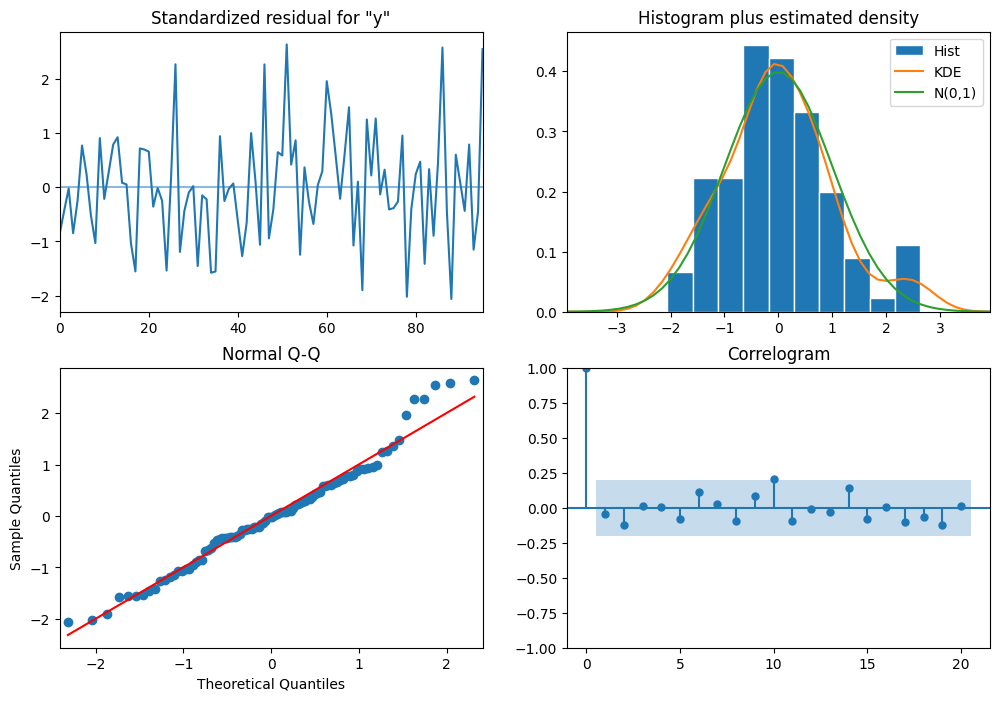

In [18]:
model_ma1.plot_diagnostics(
    figsize=(12, 8),
    lags=20
)

plt.show()

##b. Ljung–Box beberapa lag

In [19]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_ma1 = acorr_ljungbox(
    model_ma1.resid,
    lags=[10, 20],
    return_df=True
)

ljung_box_ma1

,lb_stat,lb_pvalue
10,10.142497,0.428082
20,17.769917,0.602562


##c. Uji ARCH

In [20]:
from statsmodels.stats.diagnostic import het_arch

arch_ma1 = het_arch(
    model_ma1.resid,
    nlags=10
)

print("LM Statistic :", arch_ma1[0])
print("LM p-value   :", arch_ma1[1])

LM Statistic : 13.575918642211597
LM p-value   : 0.1932285765874453


##d. Runs Test

In [21]:
from statsmodels.sandbox.stats.runs import runstest_1samp

runs_ma1 = runstest_1samp(
    model_ma1.resid,
    correction=False
)

print("Runs Statistic :", runs_ma1[0])
print("Runs p-value   :", runs_ma1[1])

Runs Statistic : -0.20102006935535702
Runs p-value   : 0.8406828812963012


##e. Uji Normalitas

In [22]:
from scipy.stats import shapiro, jarque_bera

shapiro_stat, shapiro_p = shapiro(model_ma1.resid)

jb_stat, jb_p = jarque_bera(model_ma1.resid)

print("Shapiro-Wilk")
print("Statistic :", shapiro_stat)
print("p-value   :", shapiro_p)

print("\nJarque-Bera")
print("Statistic :", jb_stat)
print("p-value   :", jb_p)

Shapiro-Wilk
Statistic : 0.974952374667063
p-value   : 0.06264319415206196

Jarque-Bera
Statistic : 3.008454983673564
p-value   : 0.22218887026737602


##Diagnostik Sisaan Model MA(1).
Berdasarkan plot diagnostik, residual model MA(1) berfluktuasi di sekitar nol tanpa menunjukkan pola sistematis, sedangkan correlogram residual menunjukkan sebagian besar autokorelasi berada dalam batas kepercayaan. Uji Ljung–Box pada lag 10 dan 20 menghasilkan \(p\text{-value}\) masing-masing sebesar 0,4281 dan 0,6026, sehingga tidak terdapat bukti autokorelasi residual yang signifikan. Uji ARCH menghasilkan \(p\text{-value}=0,1932\), yang menunjukkan tidak terdapat indikasi heteroskedastisitas bersyarat yang signifikan. Runs Test memberikan \(p\text{-value}=0,8407\), sehingga residual dapat dianggap tersusun secara acak. Pengujian normalitas dengan Shapiro–Wilk dan Jarque–Bera menghasilkan \(p\text{-value}\) masing-masing sebesar 0,0626 dan 0,2222, sehingga pada taraf nyata 5% tidak terdapat bukti yang cukup untuk menolak asumsi normalitas residual. Dengan demikian, residual model MA(1) secara umum telah memenuhi kriteria diagnostik dan dapat dianggap mendekati white noise.

#4.2. Overfitting

In [23]:
# Model awal
fit_ma1 = ARIMA(train_ma1, order=(0, 0, 1)).fit()

# Overfitting 1: menambah orde MA
fit_ma2 = ARIMA(train_ma1, order=(0, 0, 2)).fit()

# Overfitting 2: menambahkan komponen AR
fit_arma11 = ARIMA(train_ma1, order=(1, 0, 1)).fit()

In [24]:
perbandingan_ma = pd.DataFrame({
    "Model": ["MA(1)", "MA(2)", "ARMA(1,1)"],
    "AIC": [
        fit_ma1.aic,
        fit_ma2.aic,
        fit_arma11.aic
    ],
    "BIC": [
        fit_ma1.bic,
        fit_ma2.bic,
        fit_arma11.bic
    ]
})

perbandingan_ma

,Model,AIC,BIC
0,MA(1),286.038617,293.731661
1,MA(2),287.411111,297.668503
2,"ARMA(1,1)",287.603099,297.860491


In [25]:
print("===== MA(1) =====")
print(fit_ma1.summary())

print("\n===== MA(2) =====")
print(fit_ma2.summary())

print("\n===== ARMA(1,1) =====")
print(fit_arma11.summary())

===== MA(1) =====
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -140.019
Date:                Wed, 23 Sep 2026   AIC                            286.039
Time:                        02:09:55   BIC                            293.732
Sample:                             0   HQIC                           289.148
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1542      0.187     -0.825      0.410      -0.521       0.212
ma.L1          0.6817      0.092      7.432      0.000       0.502       0.862
sigma2         1.0754      0.155  

#4.3. Overfitting dan Pemilihan Model Terbaik.
Untuk mengevaluasi apakah model dengan orde yang lebih tinggi mampu memberikan peningkatan dibandingkan model MA(1), dilakukan overfitting menggunakan model MA(2) dan ARMA(1,1). Model MA(1) menghasilkan nilai AIC sebesar 286,039 dan BIC sebesar 293,732, lebih kecil dibandingkan MA(2) dengan AIC 287,411 dan BIC 297,669 serta ARMA(1,1) dengan AIC 287,603 dan BIC 297,860. Selain itu, parameter tambahan MA(2) pada model MA(2) tidak signifikan (\(p=0,464\)), sedangkan parameter AR(1) pada model ARMA(1,1) juga tidak signifikan (\(p=0,623\)). Dengan demikian, penambahan parameter tidak memberikan peningkatan model yang memadai. Berdasarkan signifikansi parameter serta kriteria AIC dan BIC, model MA(1) atau ARIMA(0,0,1) dipilih sebagai model terbaik karena lebih sederhana dan parsimonious.

#5. Forecast Data Uji

In [26]:
# Peramalan sepanjang periode data uji
forecast_ma1 = fit_ma1.get_forecast(
    steps=len(test_ma1)
)

forecast_ma1_df = forecast_ma1.summary_frame(alpha=0.05)

forecast_ma1_df.head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,1.645851,1.037004,-0.386639,3.678342
1,-0.154211,1.255053,-2.614070,2.305648
2,-0.154211,1.255053,-2.614070,2.305648
3,-0.154211,1.255053,-2.614070,2.305648
4,-0.154211,1.255053,-2.614070,2.305648


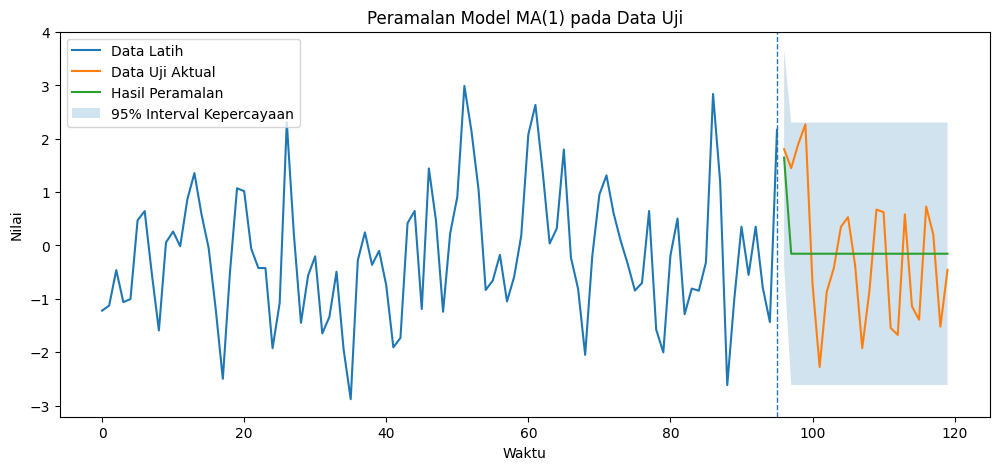

In [27]:
# Indeks waktu
train_index = np.arange(len(train_ma1))
test_index = np.arange(
    len(train_ma1),
    len(train_ma1) + len(test_ma1)
)

# Nilai ramalan
pred_test_ma1 = forecast_ma1_df["mean"].values

# Batas interval kepercayaan
lower_ci = forecast_ma1_df["mean_ci_lower"].values
upper_ci = forecast_ma1_df["mean_ci_upper"].values

plt.figure(figsize=(12, 5))

plt.plot(
    train_index,
    train_ma1,
    label="Data Latih"
)

plt.plot(
    test_index,
    test_ma1,
    label="Data Uji Aktual"
)

plt.plot(
    test_index,
    pred_test_ma1,
    label="Hasil Peramalan"
)

plt.fill_between(
    test_index,
    lower_ci,
    upper_ci,
    alpha=0.2,
    label="95% Interval Kepercayaan"
)

plt.axvline(
    x=len(train_ma1)-1,
    linestyle="--",
    linewidth=1
)

plt.title("Peramalan Model MA(1) pada Data Uji")
plt.xlabel("Waktu")
plt.ylabel("Nilai")
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error
)

# =========================
# DATA LATIH
# =========================

pred_train_ma1 = fit_ma1.fittedvalues

rmse_train_ma1 = np.sqrt(
    mean_squared_error(
        train_ma1,
        pred_train_ma1
    )
)

mape_train_ma1 = (
    mean_absolute_percentage_error(
        train_ma1,
        pred_train_ma1
    ) * 100
)


# =========================
# DATA UJI
# =========================

rmse_test_ma1 = np.sqrt(
    mean_squared_error(
        test_ma1,
        pred_test_ma1
    )
)

mape_test_ma1 = (
    mean_absolute_percentage_error(
        test_ma1,
        pred_test_ma1
    ) * 100
)


print("Evaluasi Data Latih")
print("RMSE :", rmse_train_ma1)
print("MAPE :", mape_train_ma1, "%")

print("\nEvaluasi Data Uji")
print("RMSE :", rmse_test_ma1)
print("MAPE :", mape_test_ma1, "%")

Evaluasi Data Latih
RMSE : 1.0390950876049612
MAPE : 150.65053706556063 %

Evaluasi Data Uji
RMSE : 1.1900713533057174
MAPE : 97.51103310929469 %


Peramalan dan Evaluasi Model MA(1). Model MA(1) terpilih selanjutnya digunakan untuk melakukan peramalan terhadap 24 observasi data uji. Ramalan satu langkah ke depan menghasilkan nilai 1,6459, sedangkan pada horizon berikutnya hasil ramalan kembali mendekati rata-rata model, yaitu -0,1542. Pola tersebut sesuai dengan karakteristik model MA(1), karena pengaruh innovation masa lalu hanya berlangsung selama satu periode dan innovation masa depan memiliki nilai harapan nol.

Hasil evaluasi memberikan RMSE sebesar 1,0391 pada data latih dan 1,1901 pada data uji. Nilai RMSE yang relatif berdekatan menunjukkan bahwa tidak terjadi penurunan kemampuan prediksi yang ekstrem pada data uji. Sementara itu, MAPE pada data latih dan data uji masing-masing sebesar 150,65% dan 97,51%. Nilai MAPE yang tinggi perlu diinterpretasikan secara hati-hati karena deret simulasi berfluktuasi di sekitar nol dan mengandung nilai positif maupun negatif, sehingga observasi yang mendekati nol dapat menghasilkan persentase galat yang sangat besar.

Secara keseluruhan, dengan mempertimbangkan hasil identifikasi model, signifikansi parameter, diagnostik sisaan, AIC dan BIC, serta nilai RMSE, model MA(1) telah mampu menangkap struktur deret simulasi dengan cukup baik. Meskipun demikian, hasil peramalan beberapa langkah ke depan cenderung kembali menuju rata-rata model karena shock acak pada periode mendatang tidak dapat diprediksi.

#6. AR(2) dengan  n=100  dan parameter  ϕ1=0.9  dan  ϕ2=−0.5 ; deret ARMA(1,1) dengan  n=200  dan parameter  ϕ=0.4  dan  θ=0.6

##6.1. AR(2)

In [29]:
# Simulasi deret AR(2)
# phi1 = 0.9, phi2 = -0.5, n = 100

ar2_process = ArmaProcess(
    ar=[1, -0.9, 0.5],
    ma=[1]
)

data_ar2 = ar2_process.generate_sample(
    nsample=100,
    burnin=200
)

print("Jumlah observasi:", len(data_ar2))
print(data_ar2[:10])

Jumlah observasi: 100
[-0.78503428 -0.48074872 -0.95186987 -1.09391296 -3.02062451 -2.12782759
  0.10134165  2.12503539  3.09860357  1.8519667 ]


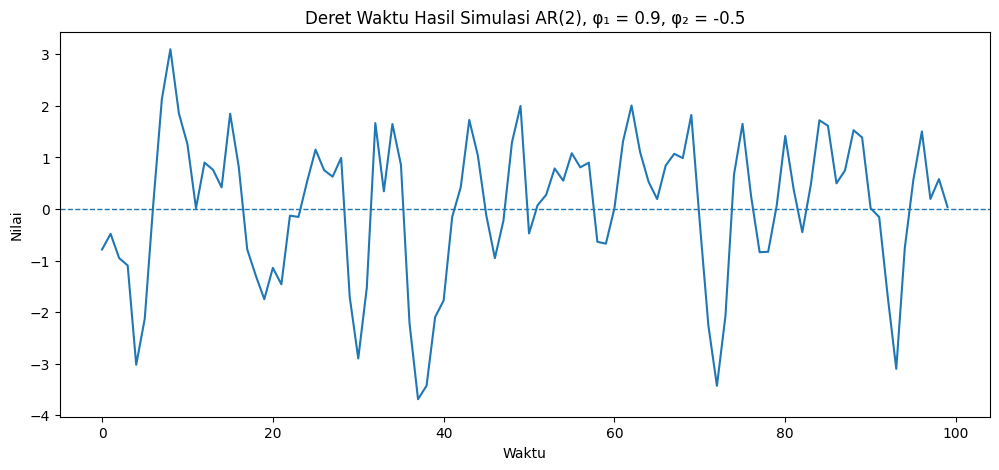

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(data_ar2)

plt.title("Deret Waktu Hasil Simulasi AR(2), φ₁ = 0.9, φ₂ = -0.5")
plt.xlabel("Waktu")
plt.ylabel("Nilai")

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.show()

Deret AR(2) disimulasikan dengan panjang amatan \(n=100\), parameter \(\phi_1=0,9\), dan \(\phi_2=-0,5\). Secara visual, deret berfluktuasi di sekitar nilai tengah yang relatif konstan dan tidak memperlihatkan tren maupun perubahan varians yang sistematis. Dibandingkan deret MA(1), pola AR(2) memperlihatkan persistensi dan gerakan naik-turun antarbeberapa periode yang lebih jelas karena nilai saat ini dipengaruhi oleh dua nilai sebelumnya. Secara visual, deret hasil simulasi menunjukkan karakteristik stasioner.

In [31]:
# Pembagian data latih dan data uji AR(2)

n_train_ar2 = int(0.8 * len(data_ar2))

train_ar2 = data_ar2[:n_train_ar2]
test_ar2 = data_ar2[n_train_ar2:]

print("Jumlah seluruh data :", len(data_ar2))
print("Jumlah data latih   :", len(train_ar2))
print("Jumlah data uji     :", len(test_ar2))

Jumlah seluruh data : 100
Jumlah data latih   : 80
Jumlah data uji     : 20


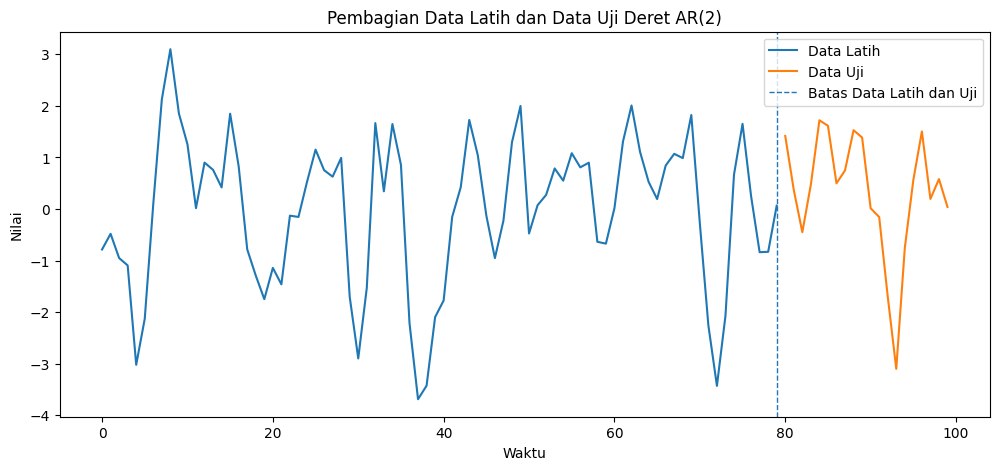

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(train_ar2)),
    train_ar2,
    label="Data Latih"
)

plt.plot(
    range(len(train_ar2), len(data_ar2)),
    test_ar2,
    label="Data Uji"
)

plt.axvline(
    x=len(train_ar2)-1,
    linestyle="--",
    linewidth=1,
    label="Batas Data Latih dan Uji"
)

plt.title("Pembagian Data Latih dan Data Uji Deret AR(2)")
plt.xlabel("Waktu")
plt.ylabel("Nilai")
plt.legend()

plt.show()

Pembagian Data Latih dan Data Uji. Deret AR(2) sebanyak 100 observasi dibagi menjadi 80% data latih dan 20% data uji. Sebanyak 80 observasi pertama digunakan sebagai data latih dan 20 observasi terakhir sebagai data uji. Pembagian dilakukan berdasarkan urutan waktu tanpa pengacakan agar struktur temporal deret tetap dipertahankan. Proporsi tersebut memberikan jumlah observasi yang cukup untuk proses identifikasi dan estimasi model sekaligus menyediakan data uji untuk mengevaluasi kemampuan peramalan.

###a. ACF dan PACF AR(2)

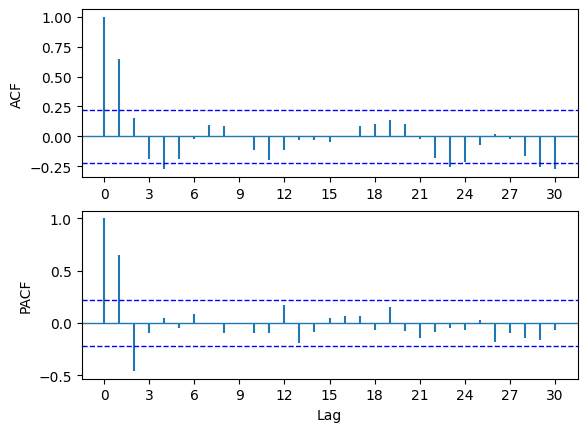

In [33]:
acf_pacf_fig(
    train_ar2,
    both=True,
    lag=30
)

plt.show()

###b. EACF AR(2)

In [34]:
train_ar2_r = np.asarray(train_ar2)

In [35]:
%%R -i train_ar2_r

library(TSA)

eacf(as.numeric(train_ar2_r))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o x o o o o o o o  o  o  o 
1 x x x x o o o o o o o  o  o  o 
2 o o o o o o o o o o o  o  o  o 
3 x o o o o o o o o o o  o  o  o 
4 x o o o o o o o o o o  o  o  o 
5 x o o o o o o o o o o  o  o  o 
6 x x o o o o o o o o o  o  o  o 
7 o x o x o o o o o o o  o  o  o 


##Identifikasi Model AR(2)
Plot ACF data latih menunjukkan pola autokorelasi yang meluruh secara bertahap dan berosilasi di sekitar nol, sehingga menunjukkan karakteristik proses autoregresif. Sementara itu, plot PACF memperlihatkan spike signifikan pada lag 1 dan lag 2, sedangkan sebagian besar lag setelahnya berada dalam batas kepercayaan, sehingga menunjukkan pola cut-off setelah lag 2. Hasil EACF juga menunjukkan pola o yang mengarah pada titik sudut \(p=2\) dan \(q=0\). Berdasarkan hasil ACF, PACF, dan EACF, model tentatif yang dipilih adalah AR(2) atau ARIMA(2,0,0).

###c. Fitting AR(2)

In [36]:
model_ar2 = ARIMA(
    train_ar2,
    order=(2, 0, 0)
).fit()

print(model_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -111.666
Date:                Wed, 23 Sep 2026   AIC                            231.332
Time:                        02:23:49   BIC                            240.860
Sample:                             0   HQIC                           235.152
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0216      0.220     -0.098      0.922      -0.453       0.410
ar.L1          0.9423      0.099      9.528      0.000       0.748       1.136
ar.L2         -0.4547      0.086     -5.291      0.0

###Pengepasan Model AR(2)
Berdasarkan hasil identifikasi ACF, PACF, dan EACF, dilakukan pengepasan model AR(2) atau ARIMA(2,0,0) terhadap 80 observasi data latih. Hasil estimasi menunjukkan koefisien AR(1) sebesar 0,9423 dan koefisien AR(2) sebesar -0,4547, dengan keduanya memiliki \(p\text{-value}<0,001\), sehingga signifikan pada taraf nyata 5%. Nilai estimasi tersebut relatif dekat dengan parameter pembangkit simulasi, yaitu \(\phi_1=0,9\) dan \(\phi_2=-0,5\). Selain itu, kedua parameter pembangkit berada dalam interval kepercayaan 95% masing-masing estimasi. Konstanta sebesar -0,0216 memiliki \(p\text{-value}=0,922\), sehingga tidak signifikan. Model menghasilkan AIC sebesar 231,332 dan BIC sebesar 240,860 yang selanjutnya akan dibandingkan dengan model hasil overfitting.

###d. Diagnostik residual AR(2)

####1) Plot diagnostik

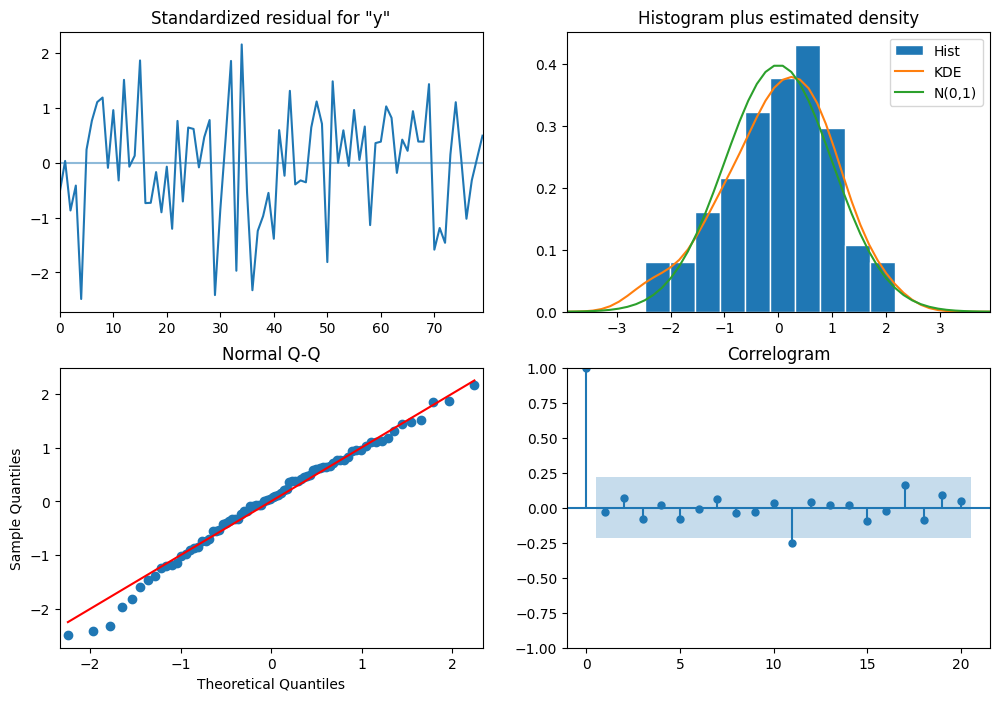

In [41]:
model_ar2.plot_diagnostics(
    figsize=(12, 8),
    lags=20
)

plt.show()

####b2) Ljung–Box lag 10 dan 20

In [42]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_ar2 = acorr_ljungbox(
    model_ar2.resid,
    lags=[10, 20],
    return_df=True
)

ljung_box_ar2

,lb_stat,lb_pvalue
10,2.389099,0.992395
20,14.613554,0.798077


####3) ARCH test

In [43]:
from statsmodels.stats.diagnostic import het_arch

arch_ar2 = het_arch(
    model_ar2.resid,
    nlags=10
)

print("LM Statistic :", arch_ar2[0])
print("LM p-value   :", arch_ar2[1])

LM Statistic : 12.98540848179709
LM p-value   : 0.22448878969853092


####4) Runs Test

In [44]:
from statsmodels.sandbox.stats.runs import runstest_1samp

runs_ar2 = runstest_1samp(
    model_ar2.resid,
    correction=False
)

print("Runs Statistic :", runs_ar2[0])
print("Runs p-value   :", runs_ar2[1])

Runs Statistic : -0.6280519027667498
Runs p-value   : 0.5299699395823114


####5) Normalitas

In [45]:
from scipy.stats import shapiro, jarque_bera

shapiro_stat, shapiro_p = shapiro(model_ar2.resid)
jb_stat, jb_p = jarque_bera(model_ar2.resid)

print("Shapiro-Wilk")
print("Statistic :", shapiro_stat)
print("p-value   :", shapiro_p)

print("\nJarque-Bera")
print("Statistic :", jb_stat)
print("p-value   :", jb_p)

Shapiro-Wilk
Statistic : 0.9847226052475437
p-value   : 0.45856052599714875

Jarque-Bera
Statistic : 1.8646870321360276
p-value   : 0.3936301500235965


###Diagnostik Sisaan Model AR(2)
Plot diagnostik menunjukkan bahwa residual berfluktuasi di sekitar nol tanpa pola sistematis, sedangkan correlogram menunjukkan sebagian besar autokorelasi residual berada dalam batas kepercayaan. Uji Ljung–Box pada lag 10 dan 20 menghasilkan \(p\text{-value}\) masing-masing sebesar 0,9924 dan 0,7981, sehingga tidak terdapat bukti autokorelasi residual yang signifikan. Uji ARCH menghasilkan \(p\text{-value}=0,2245\), yang menunjukkan tidak terdapat indikasi heteroskedastisitas bersyarat yang signifikan. Runs Test menghasilkan \(p\text{-value}=0,5300\), sehingga residual dapat dianggap tersusun secara acak. Pengujian normalitas dengan Shapiro–Wilk dan Jarque–Bera menghasilkan \(p\text{-value}\) masing-masing sebesar 0,4586 dan 0,3936, sehingga asumsi normalitas tidak ditolak pada taraf nyata 5%. Dengan demikian, residual model AR(2) secara umum telah memenuhi kriteria diagnostik dan dapat dianggap mendekati white noise.

###e. Overfitting AR(2)

In [46]:
# Model utama
fit_ar2 = ARIMA(
    train_ar2,
    order=(2, 0, 0)
).fit()

# Overfitting 1: menambah orde AR
fit_ar3 = ARIMA(
    train_ar2,
    order=(3, 0, 0)
).fit()

# Overfitting 2: menambah komponen MA
fit_arma21 = ARIMA(
    train_ar2,
    order=(2, 0, 1)
).fit()

In [47]:
perbandingan_ar2 = pd.DataFrame({
    "Model": ["AR(2)", "AR(3)", "ARMA(2,1)"],
    "AIC": [
        fit_ar2.aic,
        fit_ar3.aic,
        fit_arma21.aic
    ],
    "BIC": [
        fit_ar2.bic,
        fit_ar3.bic,
        fit_arma21.bic
    ]
})

perbandingan_ar2

,Model,AIC,BIC
0,AR(2),231.331916,240.860022
1,AR(3),232.719458,244.629591
2,"ARMA(2,1)",232.842102,244.752235


In [48]:
print("===== AR(2) =====")
print(fit_ar2.summary())

print("\n===== AR(3) =====")
print(fit_ar3.summary())

print("\n===== ARMA(2,1) =====")
print(fit_arma21.summary())

===== AR(2) =====
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -111.666
Date:                Wed, 23 Sep 2026   AIC                            231.332
Time:                        02:31:00   BIC                            240.860
Sample:                             0   HQIC                           235.152
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0216      0.220     -0.098      0.922      -0.453       0.410
ar.L1          0.9423      0.099      9.528      0.000       0.748       1.136
ar.L2         -0.4547      0.086  

###Overfitting dan Pemilihan Model Terbaik
Untuk mengevaluasi kebutuhan penambahan parameter, dilakukan overfitting menggunakan model AR(3) dan ARMA(2,1). Model AR(2) memiliki nilai AIC sebesar 231,332 dan BIC sebesar 240,860, lebih kecil dibandingkan AR(3) dengan AIC 232,719 dan BIC 244,630 serta ARMA(2,1) dengan AIC 232,842 dan BIC 244,752. Pada model AR(3), parameter tambahan AR(3) tidak signifikan dengan \(p\text{-value}=0,452\), sedangkan pada model ARMA(2,1), parameter MA(1) juga tidak signifikan dengan \(p\text{-value}=0,514\). Dengan demikian, penambahan parameter tidak memberikan peningkatan model yang memadai. Berdasarkan signifikansi parameter serta kriteria AIC dan BIC, AR(2) atau ARIMA(2,0,0) dipilih sebagai model terbaik.

###f. Forecast AR(2)

In [51]:
# Peramalan data uji AR(2)
forecast_ar2 = fit_ar2.get_forecast(
    steps=len(test_ar2)
)

forecast_ar2_df = forecast_ar2.summary_frame(alpha=0.05)

forecast_ar2_df.head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,0.428765,0.971013,-1.474385,2.331915
1,0.362813,1.334212,-2.252194,2.977821
2,0.135854,1.398967,-2.606070,2.877778
3,-0.048027,1.399105,-2.790221,2.694168
4,-0.118097,1.414751,-2.890958,2.654764


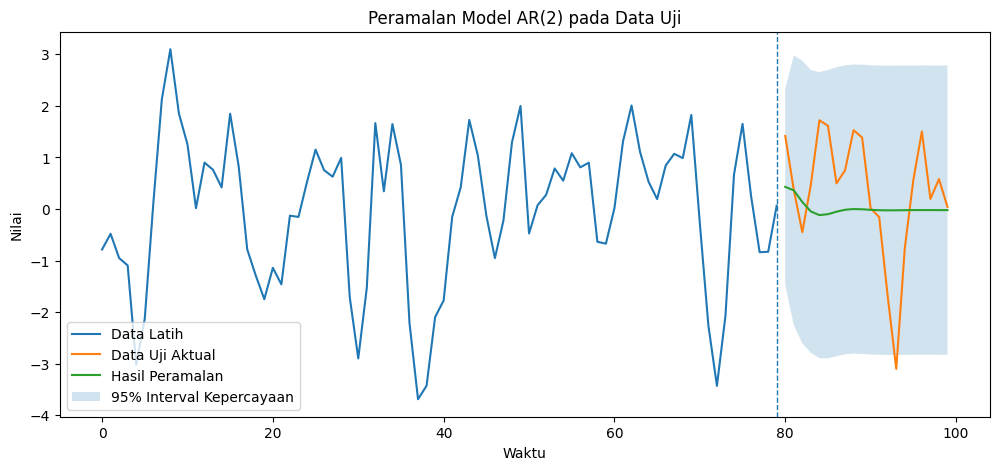

In [52]:
train_index_ar2 = np.arange(len(train_ar2))

test_index_ar2 = np.arange(
    len(train_ar2),
    len(train_ar2) + len(test_ar2)
)

pred_test_ar2 = forecast_ar2_df["mean"].values

lower_ci_ar2 = forecast_ar2_df["mean_ci_lower"].values
upper_ci_ar2 = forecast_ar2_df["mean_ci_upper"].values


plt.figure(figsize=(12, 5))

plt.plot(
    train_index_ar2,
    train_ar2,
    label="Data Latih"
)

plt.plot(
    test_index_ar2,
    test_ar2,
    label="Data Uji Aktual"
)

plt.plot(
    test_index_ar2,
    pred_test_ar2,
    label="Hasil Peramalan"
)

plt.fill_between(
    test_index_ar2,
    lower_ci_ar2,
    upper_ci_ar2,
    alpha=0.2,
    label="95% Interval Kepercayaan"
)

plt.axvline(
    x=len(train_ar2)-1,
    linestyle="--",
    linewidth=1
)

plt.title("Peramalan Model AR(2) pada Data Uji")
plt.xlabel("Waktu")
plt.ylabel("Nilai")
plt.legend()

plt.show()

In [53]:
# Prediksi data latih
pred_train_ar2 = fit_ar2.fittedvalues

# RMSE train
rmse_train_ar2 = np.sqrt(
    mean_squared_error(
        train_ar2,
        pred_train_ar2
    )
)

# MAPE train
mape_train_ar2 = (
    mean_absolute_percentage_error(
        train_ar2,
        pred_train_ar2
    ) * 100
)

# RMSE test
rmse_test_ar2 = np.sqrt(
    mean_squared_error(
        test_ar2,
        pred_test_ar2
    )
)

# MAPE test
mape_test_ar2 = (
    mean_absolute_percentage_error(
        test_ar2,
        pred_test_ar2
    ) * 100
)

print("Evaluasi Data Latih")
print("RMSE :", rmse_train_ar2)
print("MAPE :", mape_train_ar2, "%")

print("\nEvaluasi Data Uji")
print("RMSE :", rmse_test_ar2)
print("MAPE :", mape_test_ar2, "%")

Evaluasi Data Latih
RMSE : 0.9730421386096422
MAPE : 188.704306614854 %

Evaluasi Data Uji
RMSE : 1.2032031672448984
MAPE : 105.21205461056056 %


Peramalan dan Evaluasi Model AR(2). Model AR(2) yang terpilih digunakan untuk meramalkan 20 observasi data uji. Hasil peramalan menunjukkan nilai ramalan yang berosilasi dan secara bertahap mendekati nilai tengah proses. Pola tersebut sesuai dengan karakteristik model AR(2), karena pengaruh dua observasi masa lalu masih terbawa pada beberapa horizon ramalan, tetapi semakin lama pengaruh tersebut akan berkurang pada proses yang stasioner.

Hasil evaluasi menghasilkan RMSE sebesar 0,9730 pada data latih dan 1,2032 pada data uji. Nilai tersebut relatif berdekatan sehingga tidak menunjukkan penurunan performa yang ekstrem pada data uji. Sementara itu, MAPE masing-masing sebesar 188,70% dan 105,21%. Nilai MAPE yang tinggi perlu diinterpretasikan secara hati-hati karena deret simulasi berfluktuasi di sekitar nol dan mengandung nilai positif maupun negatif, sehingga observasi yang mendekati nol dapat menghasilkan persentase galat yang sangat besar.

Secara keseluruhan, berdasarkan hasil identifikasi model, signifikansi parameter, diagnostik sisaan, perbandingan AIC dan BIC, serta nilai RMSE, model AR(2) mampu merepresentasikan struktur deret hasil simulasi dengan baik

##6.2. ARMA(1,1)

In [54]:
# Simulasi deret ARMA(1,1)
# phi = 0.4, theta = 0.6, n = 200

arma11_process = ArmaProcess(
    ar=[1, -0.4],
    ma=[1, 0.6]
)

data_arma11 = arma11_process.generate_sample(
    nsample=200,
    burnin=200
)

print("Jumlah observasi:", len(data_arma11))
print(data_arma11[:10])

Jumlah observasi: 200
[ 0.70253634  0.38053177 -1.9305122  -0.07775815 -0.50135995 -2.24185728
 -3.16745607 -3.73318721 -2.36302365 -0.9082416 ]


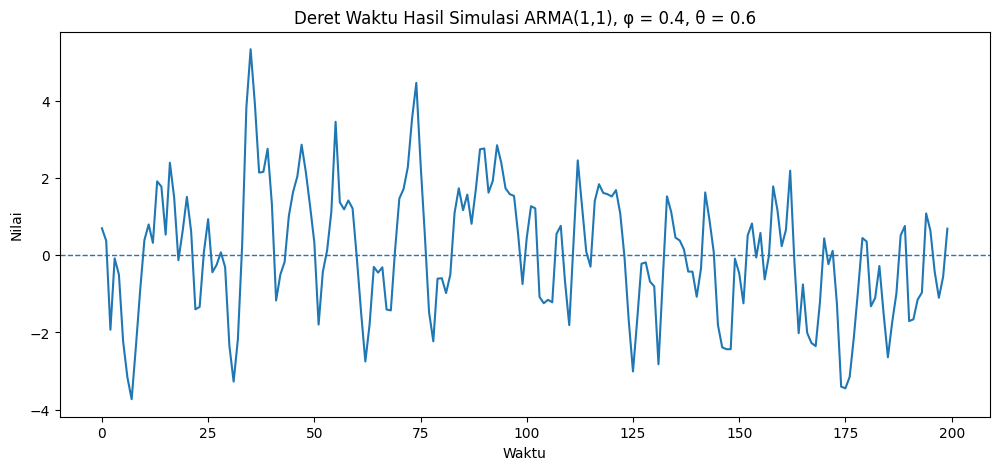

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(data_arma11)

plt.title("Deret Waktu Hasil Simulasi ARMA(1,1), φ = 0.4, θ = 0.6")
plt.xlabel("Waktu")
plt.ylabel("Nilai")

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.show()

Deret waktu ARMA(1,1) disimulasikan sebanyak 200 observasi dengan parameter autoregressive \(\phi=0,4\) dan moving average \(\theta=0,6\). Secara matematis, proses yang digunakan dapat dituliskan sebagai \(X_t=0,4X_{t-1}+\varepsilon_t+0,6\varepsilon_{t-1}\). Berdasarkan grafik hasil simulasi, deret berfluktuasi di sekitar nilai tengah yang relatif konstan dan tidak menunjukkan adanya pola tren maupun musiman. Varians deret juga terlihat relatif stabil sepanjang periode pengamatan. Dengan demikian, secara visual deret hasil simulasi menunjukkan karakteristik proses stasioner.

###a. Pembagian Data Latih dan Data Uji

In [56]:
# Membagi data ARMA(1,1) menjadi data latih dan data uji
train_size_arma11 = int(len(data_arma11) * 0.8)

train_arma11 = data_arma11[:train_size_arma11]
test_arma11 = data_arma11[train_size_arma11:]

print("Jumlah data latih :", len(train_arma11))
print("Jumlah data uji   :", len(test_arma11))

Jumlah data latih : 160
Jumlah data uji   : 40


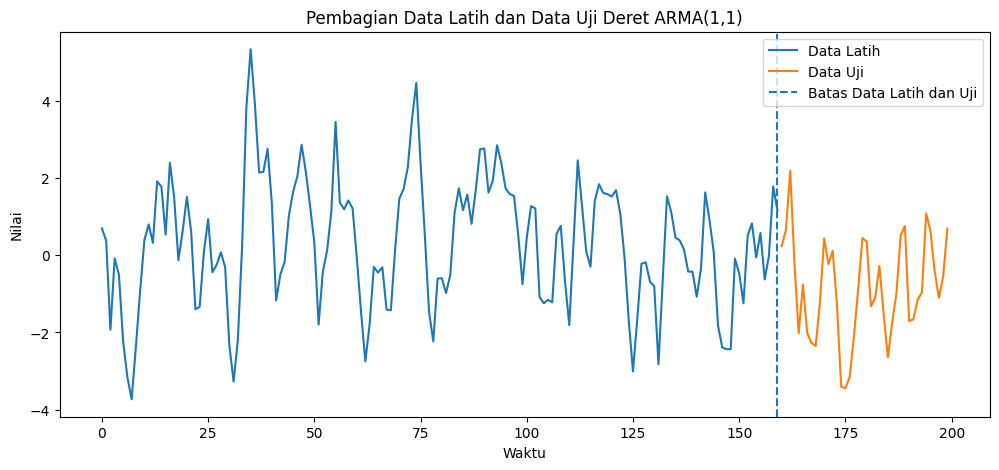

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(train_arma11)),
    train_arma11,
    label="Data Latih"
)

plt.plot(
    range(len(train_arma11), len(data_arma11)),
    test_arma11,
    label="Data Uji"
)

plt.axvline(
    x=len(train_arma11) - 1,
    linestyle="--",
    label="Batas Data Latih dan Uji"
)

plt.title("Pembagian Data Latih dan Data Uji Deret ARMA(1,1)")
plt.xlabel("Waktu")
plt.ylabel("Nilai")
plt.legend()

plt.show()

###b. ACF dan PACF

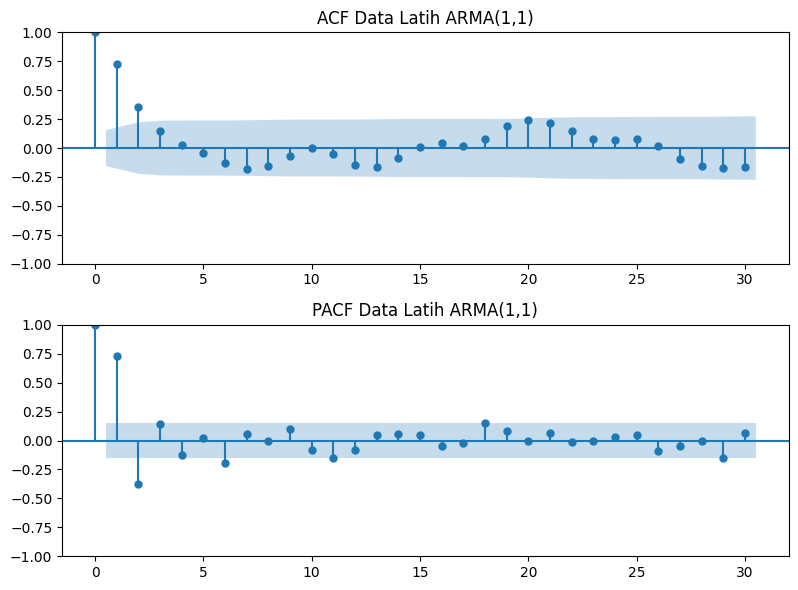

In [58]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

plot_acf(
    train_arma11,
    lags=30,
    ax=ax[0],
    alpha=0.05
)

plot_pacf(
    train_arma11,
    lags=30,
    ax=ax[1],
    alpha=0.05,
    method="ywm"
)

ax[0].set_title("ACF Data Latih ARMA(1,1)")
ax[1].set_title("PACF Data Latih ARMA(1,1)")

plt.tight_layout()
plt.show()

###c. EACF

In [64]:
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf

def eacf(data, ar_max=7, ma_max=13):
    data = np.asarray(data)

    table = []

    for p in range(ar_max + 1):

        # p = 0: tidak ada komponen AR
        if p == 0:
            resid = data - np.mean(data)

        # p > 0: fit AR(p), kemudian ambil residual
        else:
            model = AutoReg(
                data,
                lags=p,
                trend='c',
            ).fit()

            resid = model.resid

        # ACF residual
        r = acf(
            resid,
            nlags=ma_max + 1,
            fft=False
        )

        # batas signifikansi sekitar 95%
        batas = 1.96 / np.sqrt(len(resid))

        row = []

        for q in range(ma_max + 1):
            nilai = r[q + 1]

            if abs(nilai) > batas:
                row.append('x')
            else:
                row.append('o')

        table.append(row)

    # tampilkan tabel
    print("AR/MA")

    header = "   " + " ".join(
        [f"{q:>2}" for q in range(ma_max + 1)]
    )
    print(header)

    for p, row in enumerate(table):
        print(
            f"{p:<2} " +
            " ".join([f"{x:>2}" for x in row])
        )

    return table

In [65]:
eacf_table_arma11 = eacf(train_arma11, ar_max=7, ma_max=13)
print(eacf_table_arma11)

AR/MA
    0  1  2  3  4  5  6  7  8  9 10 11 12 13
0   x  x  o  o  o  o  x  o  o  o  o  o  x  o
1   x  x  o  o  o  o  o  o  o  x  o  o  x  o
2   o  o  o  o  o  o  o  o  o  o  o  o  o  o
3   o  o  o  o  o  o  o  o  o  o  o  o  o  o
4   o  o  o  o  o  o  o  o  o  o  o  o  o  o
5   o  o  o  o  o  o  o  o  o  o  o  o  o  o
6   o  o  o  o  o  o  o  o  o  o  o  o  o  o
7   o  o  o  o  o  o  o  o  o  o  o  o  o  o
[['x', 'x', 'o', 'o', 'o', 'o', 'x', 'o', 'o', 'o', 'o', 'o', 'x', 'o'], ['x', 'x', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'x', 'o', 'o', 'x', 'o'], ['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o'], ['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o'], ['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o'], ['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o'], ['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o'], ['o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o', 'o']]


###d. Perbandingan Kandidat Model Berdasarkan AIC dan BIC

In [67]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

candidates_arma11 = {
    'AR(2)': (2, 0, 0),
    'MA(2)': (0, 0, 2),
    'ARMA(1,1)': (1, 0, 1)
}

results_arma11 = []

for name, order in candidates_arma11.items():
    model = ARIMA(train_arma11, order=order)
    fit = model.fit()

    results_arma11.append({
        'Model': name,
        'AIC': fit.aic,
        'BIC': fit.bic
    })

comparison_arma11 = pd.DataFrame(results_arma11)
comparison_arma11 = comparison_arma11.sort_values('AIC').reset_index(drop=True)

comparison_arma11

,Model,AIC,BIC
0,"ARMA(1,1)",465.718712,478.019407
1,MA(2),473.693116,485.993811
2,AR(2),473.824025,486.124720


###e. Estimasi Parameter Model ARMA(1,1)

In [68]:
from statsmodels.tsa.arima.model import ARIMA

model_arma11 = ARIMA(train_arma11, order=(1, 0, 1))
fit_arma11 = model_arma11.fit()

print(fit_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -228.859
Date:                Wed, 23 Sep 2026   AIC                            465.719
Time:                        02:56:01   BIC                            478.019
Sample:                             0   HQIC                           470.714
                                - 160                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3185      0.253      1.258      0.208      -0.178       0.815
ar.L1          0.4713      0.084      5.602      0.000       0.306       0.636
ma.L1          0.6444      0.078      8.233      0.0

###f. Diagnostik Residual Model ARMA(1,1)

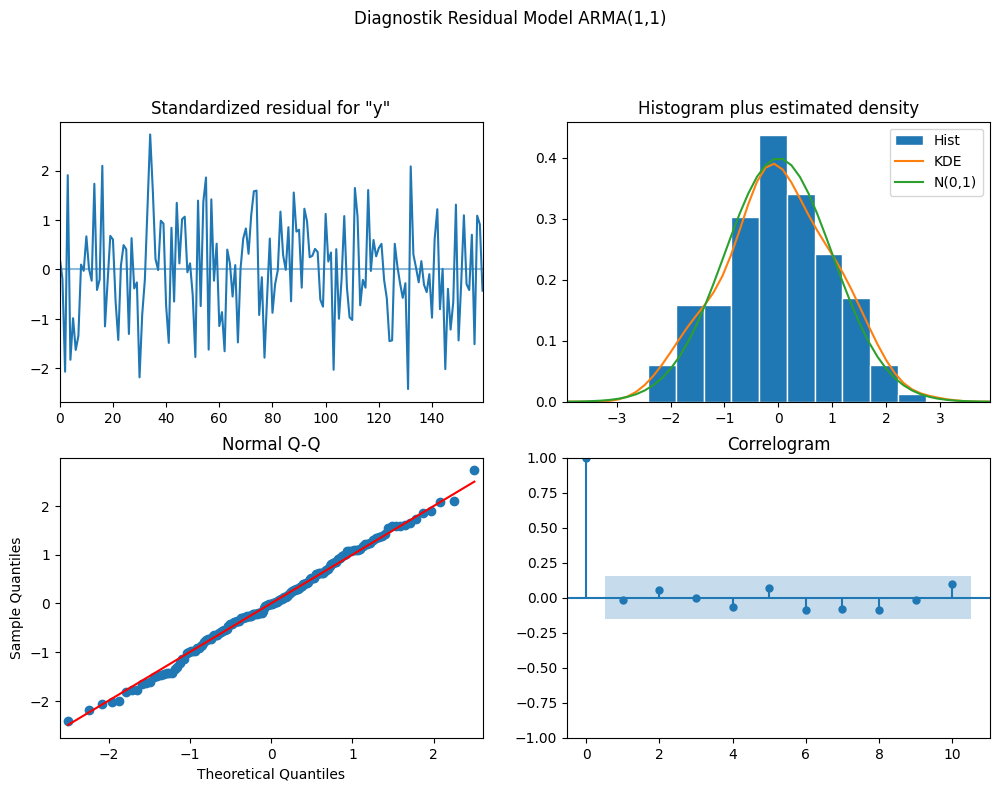

In [69]:
resid_arma11 = fit_arma11.resid

fit_arma11.plot_diagnostics(figsize=(12, 8))
plt.suptitle("Diagnostik Residual Model ARMA(1,1)", y=1.02)
plt.show()

####1) Uji Ljung Box

In [70]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_arma11 = acorr_ljungbox(
    resid_arma11,
    lags=[10, 20],
    model_df=2,
    return_df=True
)

print(ljung_box_arma11)

      lb_stat  lb_pvalue
10   7.805389   0.452708
20  19.599509   0.355812


Berdasarkan uji Ljung–Box pada lag 10 dan 20 diperoleh p-value masing-masing sebesar 0,4527 dan 0,3558. Kedua nilai tersebut lebih besar dari taraf signifikansi 5%, sehingga \(H_0\) tidak ditolak. Dengan demikian, tidak terdapat autokorelasi yang signifikan pada residual model ARMA(1,1).

####2) Uji ARCH-LM

In [71]:
from statsmodels.stats.diagnostic import het_arch

arch_test_arma11 = het_arch(resid_arma11, nlags=10)

print("LM Statistic :", arch_test_arma11[0])
print("LM p-value   :", arch_test_arma11[1])

LM Statistic : 9.286503173541567
LM p-value   : 0.5051464390344041


Berdasarkan uji ARCH-LM diperoleh nilai LM Statistic sebesar 9,2865 dengan p-value sebesar 0,5051. Karena p-value lebih besar dari taraf signifikansi 5%, maka \(H_0\) tidak ditolak. Dengan demikian, tidak terdapat efek ARCH pada residual model ARMA(1,1), sehingga residual tidak menunjukkan adanya heteroskedastisitas bersyarat.

####3) Runs Test

In [72]:
from statsmodels.sandbox.stats.runs import runstest_1samp

runs_stat_arma11, runs_pvalue_arma11 = runstest_1samp(
    resid_arma11,
    cutoff='mean'
)

print("Runs Statistic :", runs_stat_arma11)
print("Runs p-value   :", runs_pvalue_arma11)

Runs Statistic : 0.16062137829383058
Runs p-value   : 0.8723916160791182


Berdasarkan Runs Test diperoleh nilai statistik sebesar 0,1606 dengan p-value sebesar 0,8724. Karena p-value lebih besar dari taraf signifikansi 5%, maka \(H_0\) tidak ditolak. Dengan demikian, residual model ARMA(1,1) dapat dianggap bersifat acak.

####4) Uji Normalitas Residual Model ARMA(1,1)

In [74]:
from scipy.stats import shapiro, jarque_bera

# Fit model ARMA(1,1)
hasil_arma11 = model_arma11.fit()

# Ambil residual
residual_arma11 = hasil_arma11.resid

# Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residual_arma11)

# Jarque-Bera
jb_stat, jb_p = jarque_bera(residual_arma11)

print("Shapiro-Wilk")
print("Statistic :", shapiro_stat)
print("p-value   :", shapiro_p)

print("\nJarque-Bera")
print("Statistic :", jb_stat)
print("p-value   :", jb_p)

Shapiro-Wilk
Statistic : 0.994794585393827
p-value   : 0.844827044768427

Jarque-Bera
Statistic : 0.724111378148138
p-value   : 0.696243593601076


####5) Peramalan Model ARMA(1,1) pada Data Uji

In [75]:
# Forecast sebanyak jumlah data uji
forecast_arma11 = hasil_arma11.get_forecast(steps=len(test_arma11))

# Nilai prediksi
pred_arma11 = forecast_arma11.predicted_mean

# Confidence interval 95%
conf_int_arma11 = forecast_arma11.conf_int()

print("Hasil Forecast ARMA(1,1)")
print(pred_arma11)

Hasil Forecast ARMA(1,1)
[0.44343432 0.37740697 0.34628578 0.33161718 0.32470332 0.32144455
 0.31990857 0.31918461 0.31884337 0.31868254 0.31860673 0.318571
 0.31855416 0.31854622 0.31854248 0.31854072 0.31853988 0.31853949
 0.31853931 0.31853922 0.31853918 0.31853916 0.31853915 0.31853915
 0.31853914 0.31853914 0.31853914 0.31853914 0.31853914 0.31853914
 0.31853914 0.31853914 0.31853914 0.31853914 0.31853914 0.31853914
 0.31853914 0.31853914 0.31853914 0.31853914]


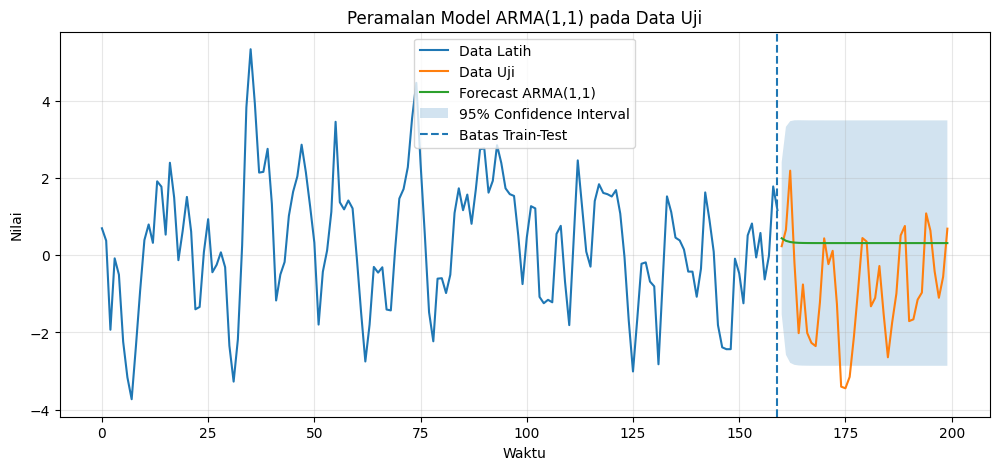

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Indeks
train_index = np.arange(len(train_arma11))
test_index = np.arange(
    len(train_arma11),
    len(train_arma11) + len(test_arma11)
)

# Confidence interval
ci_arma11 = np.asarray(conf_int_arma11)

plt.figure(figsize=(12, 5))

plt.plot(
    train_index,
    train_arma11,
    label='Data Latih'
)

plt.plot(
    test_index,
    test_arma11,
    label='Data Uji'
)

plt.plot(
    test_index,
    pred_arma11,
    label='Forecast ARMA(1,1)'
)

plt.fill_between(
    test_index,
    ci_arma11[:, 0],
    ci_arma11[:, 1],
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.axvline(
    x=len(train_arma11)-1,
    linestyle='--',
    label='Batas Train-Test'
)

plt.title('Peramalan Model ARMA(1,1) pada Data Uji')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

####6) Evaluasi Akurasi Model ARMA(1,1)

In [77]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Prediksi data latih
pred_train_arma11 = hasil_arma11.fittedvalues

# Evaluasi data latih
rmse_train_arma11 = np.sqrt(
    mean_squared_error(train_arma11, pred_train_arma11)
)
mae_train_arma11 = mean_absolute_error(
    train_arma11, pred_train_arma11
)
mape_train_arma11 = mean_absolute_percentage_error(
    train_arma11, pred_train_arma11
) * 100

# Evaluasi data uji
rmse_test_arma11 = np.sqrt(
    mean_squared_error(test_arma11, pred_arma11)
)
mae_test_arma11 = mean_absolute_error(
    test_arma11, pred_arma11
)
mape_test_arma11 = mean_absolute_percentage_error(
    test_arma11, pred_arma11
) * 100

print("Evaluasi Data Latih")
print("RMSE :", rmse_train_arma11)
print("MAE  :", mae_train_arma11)
print("MAPE :", mape_train_arma11, "%")

print("\nEvaluasi Data Uji")
print("RMSE :", rmse_test_arma11)
print("MAE  :", mae_test_arma11)
print("MAPE :", mape_test_arma11, "%")

Evaluasi Data Latih
RMSE : 1.0093324469797147
MAE  : 0.8065981811735478
MAPE : 200.6457032584854 %

Evaluasi Data Uji
RMSE : 1.745608982145796
MAE  : 1.4088163333721637
MAPE : 114.74152638234531 %


Berdasarkan hasil evaluasi, model ARMA(1,1) menghasilkan RMSE sebesar 1,0093 dan MAE sebesar 0,8066 pada data latih. Pada data uji, diperoleh RMSE sebesar 1,7456 dan MAE sebesar 1,4088. Nilai MAPE relatif sangat besar karena data simulasi mengandung nilai negatif dan nilai yang mendekati nol, sehingga MAPE kurang tepat digunakan sebagai ukuran utama akurasi. Oleh karena itu, evaluasi model lebih difokuskan pada nilai RMSE dan MAE.

#Kesimpulan Akhir

Berdasarkan hasil simulasi dan analisis tiga model deret waktu, yaitu MA(1), AR(2), dan ARMA(1,1), proses identifikasi melalui ACF, PACF, dan EACF mampu memberikan informasi mengenai kandidat model yang sesuai. Selanjutnya, pemilihan model dilakukan dengan membandingkan nilai AIC dan BIC serta mempertimbangkan signifikansi parameter.

Pada simulasi MA(1) dengan parameter \(\theta=0.6\), diperoleh model MA(1) dengan estimasi parameter \(\hat{\theta}=0.6817\). Pada simulasi AR(2) dengan \(\phi_1=0.9\) dan \(\phi_2=-0.5\), diperoleh estimasi masing-masing sebesar \(0.9423\) dan \(-0.4547\). Sementara itu, pada simulasi ARMA(1,1) dengan \(\phi=0.4\) dan \(\theta=0.6\), diperoleh estimasi \(\hat{\phi}=0.4713\) dan \(\hat{\theta}=0.6444\). Secara umum, parameter hasil estimasi cukup mendekati parameter yang digunakan dalam proses simulasi.

Berdasarkan diagnostik residual, ketiga model tidak menunjukkan autokorelasi residual yang signifikan, tidak menunjukkan efek ARCH, residual bersifat acak, dan memenuhi asumsi normalitas. Oleh karena itu, model yang diperoleh dapat dianggap memadai untuk merepresentasikan masing-masing data simulasi.

Hasil peramalan menunjukkan bahwa nilai RMSE pada data uji masing-masing sebesar 1.1901 untuk MA(1), 1.2032 untuk AR(2), dan 1.7456 untuk ARMA(1,1). Nilai MAPE relatif besar karena data simulasi dapat memiliki nilai negatif maupun nilai yang mendekati nol. Oleh sebab itu, MAPE kurang sesuai dijadikan ukuran utama dalam kasus ini dan evaluasi lebih tepat difokuskan pada RMSE dan MAE.